In [2]:
###Initial Set-Up

#Import Necessary Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all our plots
sns.set_style('whitegrid')
sns.set_palette('deep')

#Import the Data
nhts_data = pd.read_csv('NHTS.csv')
ngsim_data = pd.read_csv('NGSIM.csv')

#Visualize color palettes
print(sns.palettes.SEABORN_PALETTES.keys())

dict_keys(['deep', 'deep6', 'muted', 'muted6', 'pastel', 'pastel6', 'bright', 'bright6', 'dark', 'dark6', 'colorblind', 'colorblind6'])


fuel_type
Gas                                  13485
Hybrid, gas/electric, non plug-in      477
Diesel                                 384
Electric only                          186
Plug-in hybrid                          80
Uses other fuel                         34
Biodiesel                                6
Name: count, dtype: int64


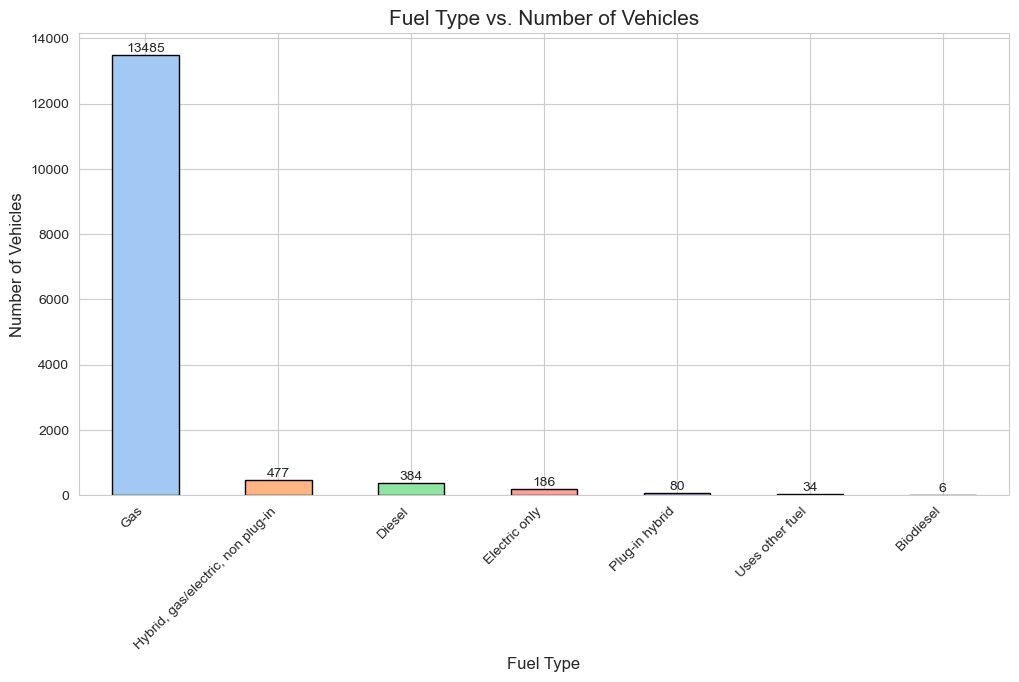

In [2]:
###Bar Chart
 ##Compares Fuel Type and Number of Vehicles

# First count the values
 # use dropna to remove missing values
fuel_counts = nhts_data['fuel_type'].value_counts().dropna()
print(fuel_counts)

## Step 1: count the number of vehicles by fuel type
plt.figure(figsize = (12,6))
xaxis = fuel_counts.plot(kind = 'bar', color = sns.color_palette('pastel', len(fuel_counts)), edgecolor = 'black') 
xaxis.bar_label(xaxis.containers[0])

## Step 2: create the bar plot
## Step 3: Add labels and customization
plt.xlabel('Fuel Type', fontsize = 12)
plt.xticks(rotation = 45, ha = 'right')
plt.ylabel('Number of Vehicles', fontsize = 12)
plt.title('Fuel Type vs. Number of Vehicles', fontsize = 15)

## Step 4: show the plot
plt.savefig("FuelType vs. Number of Vehicles (Bar Chart).png", dpi = 300, bbox_inches = "tight")
plt.show()


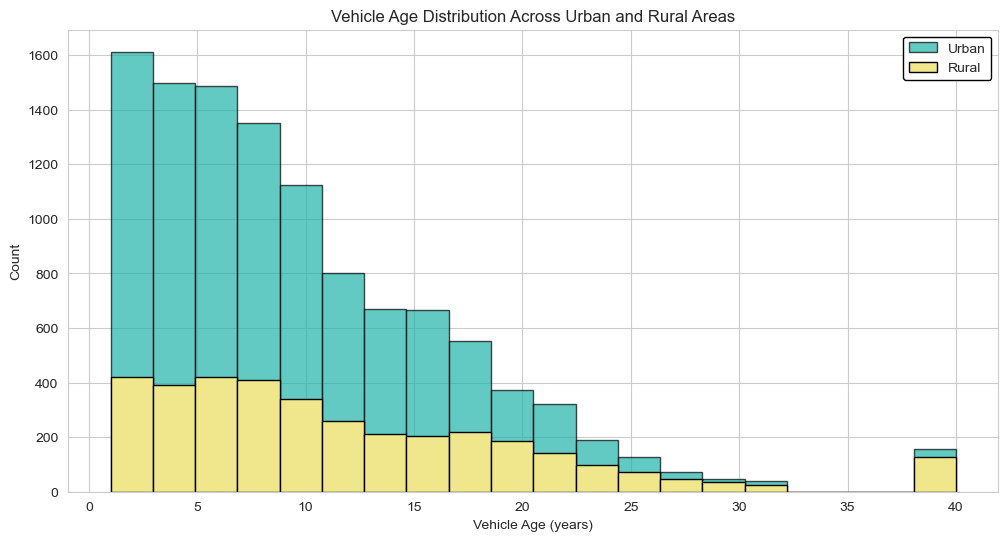

In [3]:
###Histogram
 ##Distribution of Vehicle Age Across Urban and Rural Areas

## Step 1: Tell Python you are making a figure
plt.figure(figsize = (12,6))

## Step 2: Filter and plot Urban vehicle ages
urban_ages = nhts_data[nhts_data['household_location'] == 'Urban']['vehicle_age']

plt.hist(urban_ages, bins = 20, edgecolor = 'black', alpha = 0.7, color = 'lightseagreen', label = 'Urban')

## Step 3: Filter and plot Rural vehicle ages on the same figure
rural_ages = nhts_data[nhts_data['household_location'] == 'Rural']['vehicle_age']
plt.hist(rural_ages, bins = 20, edgecolor = 'black', alpha = 1, color = 'khaki', label = 'Rural')
         
## Step 4: Add labels, title, and a legend
plt.xlabel('Vehicle Age (years)')
plt.ylabel('Count')
plt.title('Vehicle Age Distribution Across Urban and Rural Areas')
plt.legend(edgecolor = 'black', facecolor = 'white', framealpha = 1)

plt.savefig("Vehicle Age Distribution Across Urban and Rural Areas (Histogram).png", dpi = 300, bbox_inches = "tight")
plt.show()


C:\Users\rylee\AppData\Local\Temp\ipykernel_33472\167720286.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = nhts_data, y = 'vehicle_age', x = 'make', palette = 'crest')


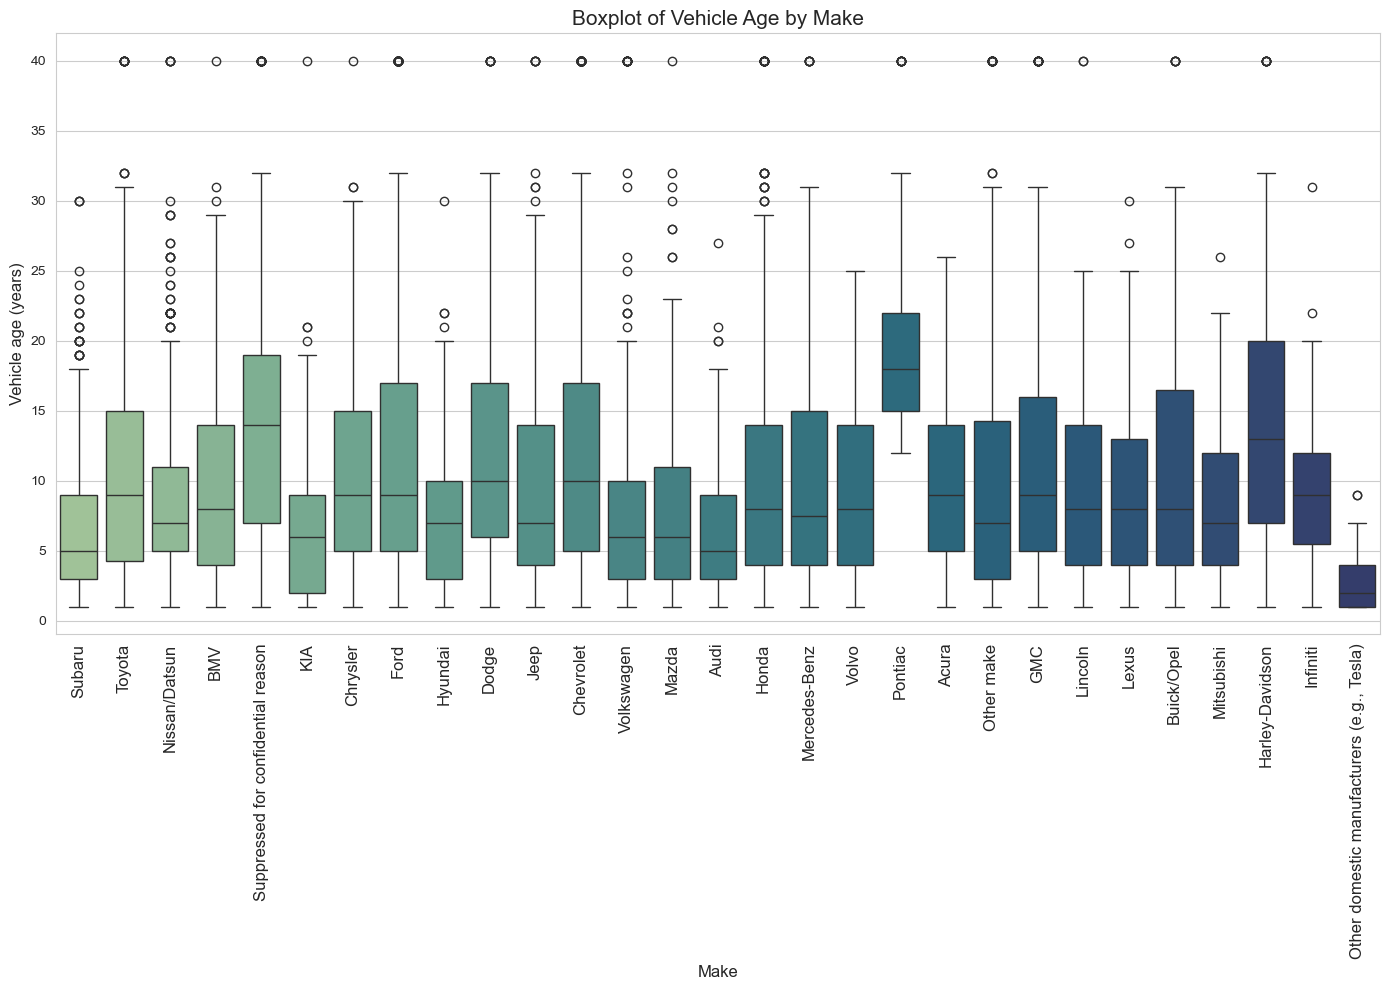

In [4]:
###Boxplot
 ##shows distribution of vehicle ages across different vehicle makes

## Step 1: Tell Python you are making a figure and the preferred size
plt.figure(figsize = (14,10))

## Step 2: Call the type of plot and tell the function what variables you want to plot
sns.boxplot(data = nhts_data, y = 'vehicle_age', x = 'make', palette = 'crest')

## Step 3: Add customization
                            
plt.xticks(rotation = 90, fontsize = 12)
plt.xlabel('Make', fontsize = 12)
plt.ylabel('Vehicle age (years)', fontsize = 12)
plt.title('Boxplot of Vehicle Age by Make', fontsize = 15)
                            
## Step 4: Show the plot
plt.tight_layout()
plt.savefig("Vehicle Age by Make (Boxplot).png", dpi = 300, bbox_inches = "tight")
plt.show()

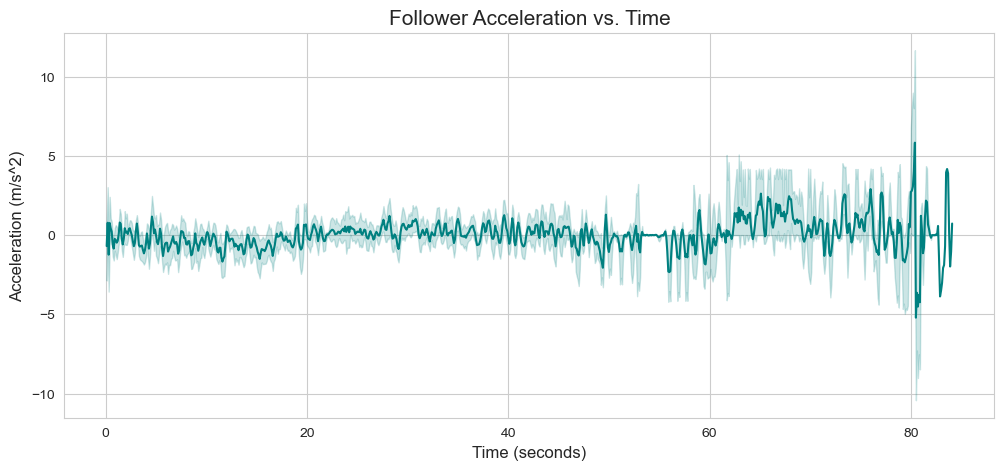

In [5]:
###Time Series Plot 1
 ##analyzing leader acceleration with respect to time

# Step 1: Tell python that you want to plot and choose a size 
plt.figure(figsize = (12,5))

# Step 2: Create a Time-Series Plot
sns.lineplot(x = ngsim_data['Time'], y = ngsim_data['follower_acc(m/s^2)'], color = 'teal')

# Step 3: Add customizations
plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Acceleration (m/s^2)', fontsize = 12)
plt.title('Follower Acceleration vs. Time', fontsize = 15)

plt.savefig("Follower Accerleration vs Time (Time 1).png", dpi = 300, bbox_inches = "tight")
plt.show()

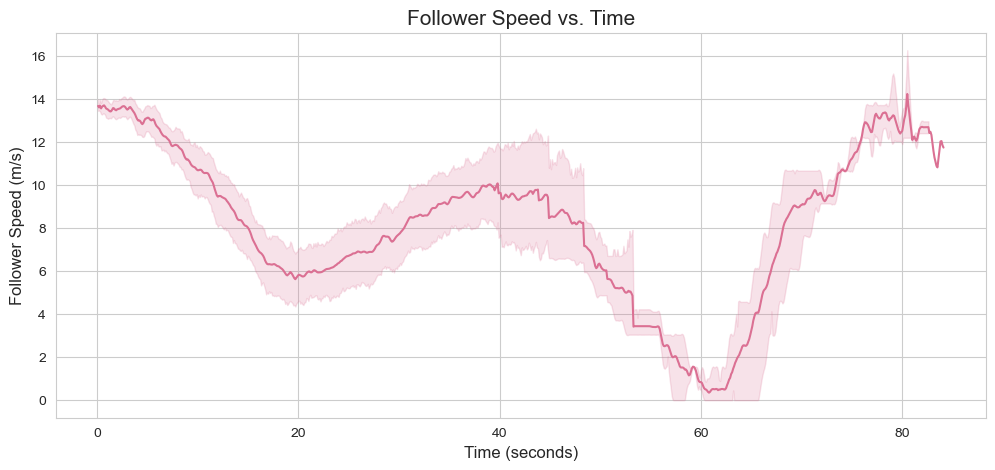

In [6]:
###Time Series Plot 2
 ##analyzing leader speed with respect to time

# Step 1: Tell python that you want to plot and choose a size 
plt.figure(figsize = (12,5))

sns.lineplot(x = ngsim_data['Time'], y = ngsim_data['follower_speed(m/s)'], color = 'palevioletred')

# Step 3: add customizations
plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Follower Speed (m/s)', fontsize = 12)
plt.title('Follower Speed vs. Time', fontsize = 15)

plt.savefig("Follower Speed vs. Time (Time 2).png", dpi = 300, bbox_inches = "tight")
plt.show()


 Time Step: 0.1000 s


Enter desired velocity (m/s):  40
Enter minimum spacing (m):  2
Enter desired time headway (s):  1.5
Enter maximum acceleration (m/s^2):  1.0
Enter comfortable deceleration (m/s^2):  2
Enter acceleration exponent:  4


Simulation complete!


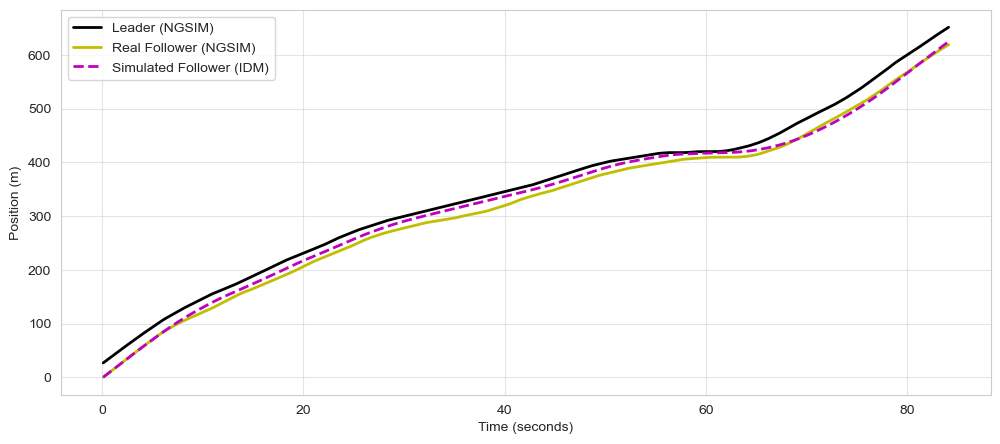

<Figure size 640x480 with 0 Axes>

In [13]:
###Simulation Study

##Step 1 - Define the IDM acceleration function

# The function contains following inputs:
#   v      : current speed of the follower vehicle (m/s)
#   s      : current gap distance between leader and follower (m)
#   delta_v : speed difference = follower speed - leader speed (m/s)
#   v0     : desired velocity (m/s)
#   s0     : minimum spacing (m)
#   T      : desired time headway (s)
#   a      : maximum acceleration (m/s^2)
#   b      : comfortable deceleration (m/s^2)
#   delta  : acceleration exponent

def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):

# Step 1: Calculate the desired minimum gap s_star
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    
# Make sure s_star is not negative
    s_star = max(s_star, s0)
    
# Step 2: Calculate the acceleration using the IDM equation
    acceleration = a *(1 - (v/v0)**delta - (s_star/s)**2)
    
    return acceleration

##Step 2 - Set up the simulation

# Select a trajectory pair
trajectory_number = 1

# Extract the leader's position and speed over time
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop=True)
leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values
time_data = data_subset['Time'].values

# Identify the time step
dt = time_data[1] - time_data[0]
print(f" Time Step: {dt:.4f} s")

##Step 3 - Run the simulation

# Input the IDM parameters
v0 = float(input("Enter desired velocity (m/s): "))
s0 = float(input("Enter minimum spacing (m): "))    
T = float(input("Enter desired time headway (s): "))   
a_param = float(input("Enter maximum acceleration (m/s^2): ")) 
b = float(input("Enter comfortable deceleration (m/s^2): "))  
delta = float(input("Enter acceleration exponent: "))

# Initialize arrays to store simulation results
         # number of simulation steps we will take
         # simulated follower position with a vector with all zeroes
         # simulated follower speed with a vector with all zeroes
         # simulated follower acceleration with a vector with all zeroes

n_steps = len(time_data)
sim_position = np.zeros(n_steps)
sim_speed = np.zeros(n_steps)
sim_acceleration = np.zeros(n_steps)

# Start at the real follower's initial state
        #this makes the starting value [0] same as the follower vehicle position
        #this makes the starting value [0] same as the follower vehicle speed

sim_position[0] = data_subset['follower_position(m)'].values[0]
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]

# Run the IDM simulation
# loop through each time step and calculate:
#   1. The gap between the leader and follower
#   2. The speed difference between the two vehicles
#   3. The IDM acceleration
#   4. The updated speed using: new_speed = old_speed + acceleration * dt
#   5. The updated position using: new_position = old_position + speed * dt

for i in range(n_steps - 1): # we do -1 since the first element is known (remember the step above) 

    # Step 1 & 2: Calculate the gap and speed difference at this time step
    gap = max(leader_position[i] - sim_position[i], 0.1) #just a condition to make sure it is not negative
    delta_v = sim_speed[i] - leader_speed[i]

    # Step 3: Use the IDM function to calculate acceleration
    sim_acceleration[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a_param, b, delta)

    # Step 4 & 5: Update speed and position for the next time step
    sim_speed[i+1] = sim_speed[i] + sim_acceleration[i] * dt #this updates my speed for next iteration
    sim_position[i+1] = sim_position[i] + sim_speed[i] * dt

print("Simulation complete!")

##Visualize simulation results

plt.figure(figsize = (12,5))
plt.plot(time_data, leader_position, 'k-', linewidth = 2, label = 'Leader (NGSIM)') #plots leader position vs. time
plt.plot(time_data, data_subset['follower_position(m)'].values, 'y-', linewidth = 2, label = 'Real Follower (NGSIM)') #plots actual 
plt.plot(time_data, sim_position, 'm--', linewidth = 2, label = 'Simulated Follower (IDM)')
plt.xlabel('Time (seconds)')
plt.ylabel('Position (m)')
plt.legend()
plt.grid(True, alpha = 0.5)
plt.show()
plt.savefig("Simulation Study.png", dpi = 300, bbox_inches = "tight")
